# Notebook 04 — Reorder Point & Safety Stock
**Tujuan:** Hitung ROP dan safety stock per produk Kelas A berdasarkan demand historis dan lead time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

OUT     = Path('../output')
FIGURES = OUT / 'figures'

BLUE  = '#2563EB'
RED   = '#DC2626'
AMBER = '#F59E0B'
GREEN = '#059669'
GRAY  = '#6B7280'
LIGHT = '#93C5FD'

Z_SERVICE = 1.645  # 95% service level

df  = pd.read_parquet(OUT / 'df_clean.parquet')
abc = pd.read_parquet(OUT / 'df_abc.parquet')

qty_col = [c for c in df.columns if 'order_item_quantity' in c or ('quantity' in c and 'order' in c)][0]
print(f'Quantity col: {qty_col}')
print(f'Loaded: {len(df):,} transaksi, {len(abc):,} produk')

Quantity col: order_item_quantity
Loaded: 180,519 transaksi, 118 produk


## 1. Filter Produk Kelas A

In [2]:
class_a_products = abc[abc['abc_class'] == 'A']['product_name'].tolist()
df_a = df[df['product_name'].isin(class_a_products)].copy()
print(f'Produk kelas A: {len(class_a_products):,}')
print(f'Transaksi kelas A: {len(df_a):,}')

Produk kelas A: 7
Transaksi kelas A: 126,519


## 2. Hitung Demand Harian & Lead Time per Produk

In [3]:
# Identifikasi kolom tanggal order
date_col = [c for c in df.columns if 'order_date' in c or 'dateorders' in c][0]

# Total hari dalam dataset
total_days = (df[date_col].max() - df[date_col].min()).days
total_days = max(total_days, 1)
print(f'Rentang data: {total_days} hari')

# Hitung demand harian per produk
demand_stats = (
    df_a.groupby(['product_name', df_a[date_col].dt.date])[qty_col]
    .sum()
    .reset_index()
    .groupby('product_name')[qty_col]
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'avg_daily_demand', 'std': 'std_daily_demand'})
    .fillna(0)
)

# Lead time per produk
lead_stats = (
    df_a.groupby('product_name')['actual_lead_time']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'avg_lead_time', 'std': 'std_lead_time'})
    .fillna(1)
)

rop_df = demand_stats.join(lead_stats)
rop_df['avg_lead_time'] = rop_df['avg_lead_time'].clip(lower=1)
print(f'ROP dataframe: {len(rop_df):,} produk')

Rentang data: 1126 hari
ROP dataframe: 7 produk


## 3. Hitung Safety Stock & Reorder Point

In [4]:
# Safety Stock = Z × σ_demand × √(avg_lead_time)
rop_df['safety_stock'] = (
    Z_SERVICE
    * rop_df['std_daily_demand']
    * np.sqrt(rop_df['avg_lead_time'])
).round(1)

# Reorder Point = (avg_daily_demand × avg_lead_time) + safety_stock
rop_df['rop'] = (
    rop_df['avg_daily_demand'] * rop_df['avg_lead_time']
    + rop_df['safety_stock']
).round(1)

# Max stock = ROP + avg_daily_demand × avg_lead_time
rop_df['max_stock'] = (
    rop_df['rop'] + rop_df['avg_daily_demand'] * rop_df['avg_lead_time']
).round(1)

# Flag: jika avg_daily_demand rendah → potensi reorder alert
rop_df['reorder_alert'] = (
    rop_df['avg_daily_demand'] < rop_df['rop'] / rop_df['avg_lead_time'].clip(lower=1)
)

rop_df = rop_df.reset_index()
print(rop_df[['product_name','avg_daily_demand','avg_lead_time',
              'safety_stock','rop','reorder_alert']].head(10).to_string(index=False))

                                 product_name  avg_daily_demand  avg_lead_time  safety_stock   rop  reorder_alert
Diamondback Women's Serene Classic Comfort Bi         13.647117       3.498215          11.5  59.2           True
    Field & Stream Sportsman 16 Gun Fire Safe         17.221670       3.502049          13.1  73.4           True
      Nike Men's CJ Elite 2 TD Football Cleat         22.113320       3.501259          15.0  92.4           True
         Nike Men's Dri-FIT Victory Golf Polo         62.580517       3.484716          49.1 267.2           True
            Nike Men's Free 5.0+ Running Shoe         36.461233       3.493960          37.2 164.6           True
                  Pelican Sunstream 100 Kayak         15.407555       3.483032          12.5  66.2           True
             Perfect Fitness Perfect Rip Deck         73.258449       3.506384          51.5 308.4           True


## 4. Visualisasi Reorder Point

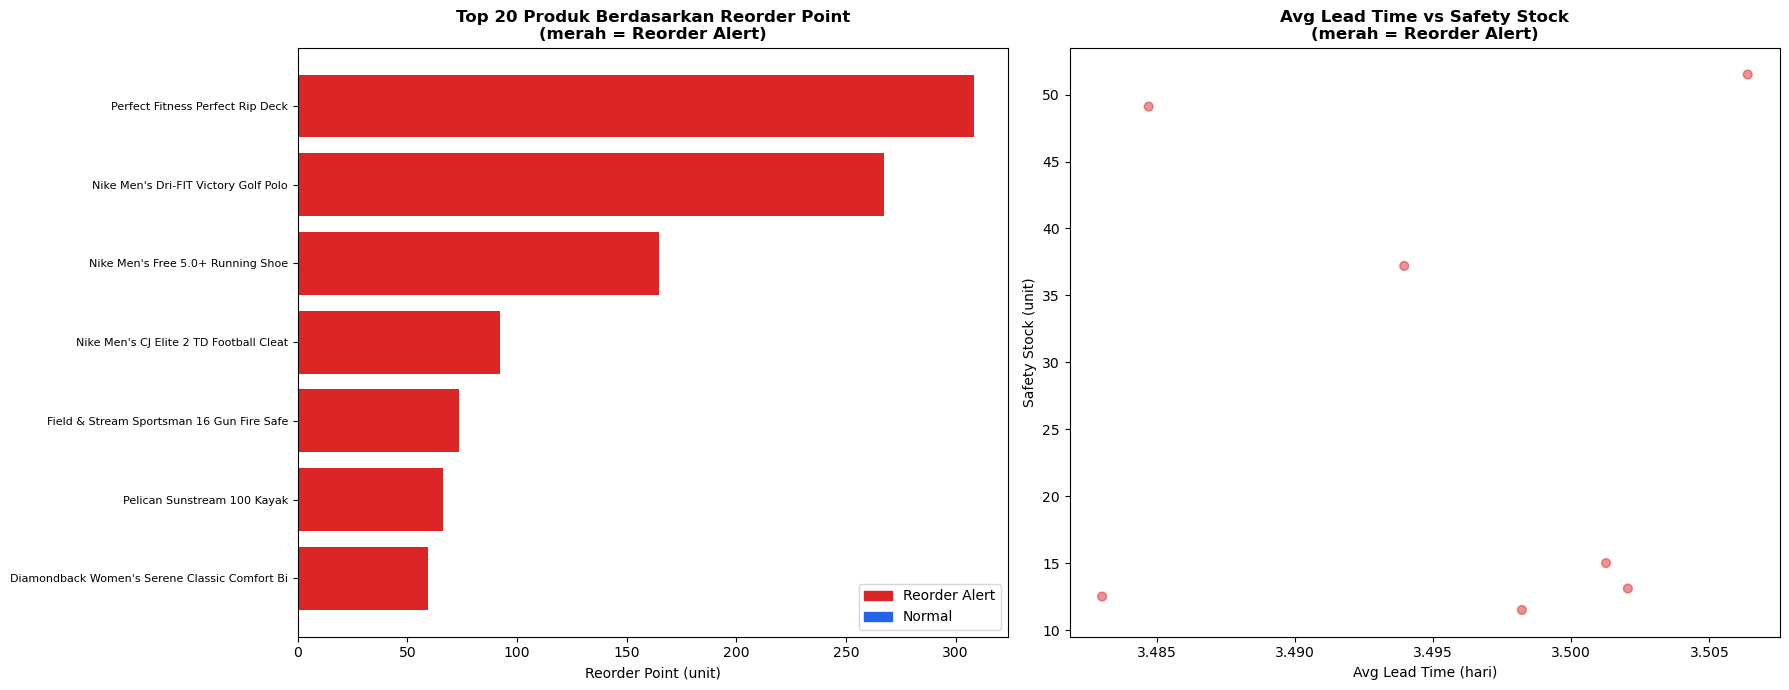

Saved: G_reorder_point.png


In [5]:
top20 = rop_df.nlargest(20, 'rop').sort_values('rop')
bar_colors = [RED if alert else BLUE for alert in top20['reorder_alert']]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart ROP top 20
axes[0].barh(top20['product_name'], top20['rop'], color=bar_colors)
axes[0].set_xlabel('Reorder Point (unit)')
axes[0].set_title('Top 20 Produk Berdasarkan Reorder Point\n(merah = Reorder Alert)', fontweight='bold')
axes[0].tick_params(axis='y', labelsize=8)
import matplotlib.patches as mpatches
axes[0].legend(handles=[
    mpatches.Patch(color=RED,  label='Reorder Alert'),
    mpatches.Patch(color=BLUE, label='Normal')
], loc='lower right')

# Scatter lead time vs safety stock
axes[1].scatter(
    rop_df['avg_lead_time'],
    rop_df['safety_stock'],
    c=[RED if a else BLUE for a in rop_df['reorder_alert']],
    alpha=0.5, s=40
)
axes[1].set_xlabel('Avg Lead Time (hari)')
axes[1].set_ylabel('Safety Stock (unit)')
axes[1].set_title('Avg Lead Time vs Safety Stock\n(merah = Reorder Alert)', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / 'G_reorder_point.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: G_reorder_point.png')

## 5. Tabel Reorder Ringkasan & Simpan

In [6]:
print('=== TOP 20 PRODUK — REORDER SUMMARY ===')
print(top20[['product_name','avg_daily_demand','avg_lead_time',
             'safety_stock','rop','max_stock','reorder_alert']]
      .round(1).to_string(index=False))

rop_df.to_parquet(OUT / 'df_reorder.parquet', index=False)
print(f'\nTersimpan: df_reorder.parquet — {len(rop_df):,} produk kelas A')
print(f'Produk dengan Reorder Alert: {rop_df["reorder_alert"].sum():,}')

=== TOP 20 PRODUK — REORDER SUMMARY ===
                                 product_name  avg_daily_demand  avg_lead_time  safety_stock   rop  max_stock  reorder_alert
Diamondback Women's Serene Classic Comfort Bi              13.6            3.5          11.5  59.2      106.9           True
                  Pelican Sunstream 100 Kayak              15.4            3.5          12.5  66.2      119.9           True
    Field & Stream Sportsman 16 Gun Fire Safe              17.2            3.5          13.1  73.4      133.7           True
      Nike Men's CJ Elite 2 TD Football Cleat              22.1            3.5          15.0  92.4      169.8           True
            Nike Men's Free 5.0+ Running Shoe              36.5            3.5          37.2 164.6      292.0           True
         Nike Men's Dri-FIT Victory Golf Polo              62.6            3.5          49.1 267.2      485.3           True
             Perfect Fitness Perfect Rip Deck              73.3            3.5       